Importando as bibliotecas e módulos necessários: 

In [23]:
#!pip install matplotlib
#!pip install pyarrow
import os
import pandas as pd
import numpy as np
import sys
import gc
import matplotlib.pyplot as plt

Carregando a base a ser utilizada:

In [2]:
df_final = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_UNIF.parquet", engine="pyarrow")

### Análise Exploratória dos dados
Esta seção concentra-se na discussão das principais descobertas da análise exploratória de dados (AED). Em particular, três questões de AED foram formuladas e investigadas com o uso de resumos numéricos (medidas de tendência central, medidas de dispersão e correlação). Informações adicionais também puderam ser obtidas a partir de suas respectivas visualizações.

#### 1. Distribuição das Variáveis
O objetivo dessa fase foi comparar as respostas para as variáveis categóricas entre os anos

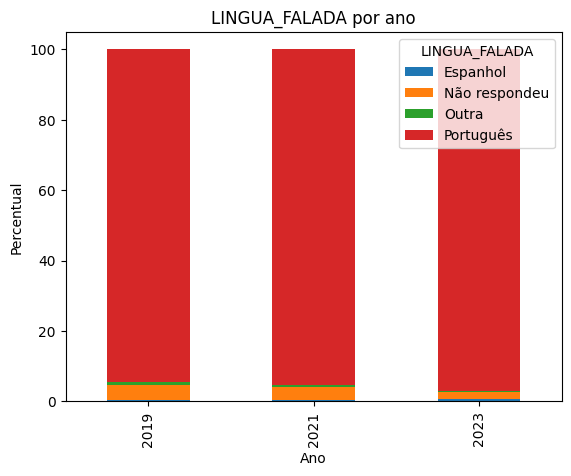

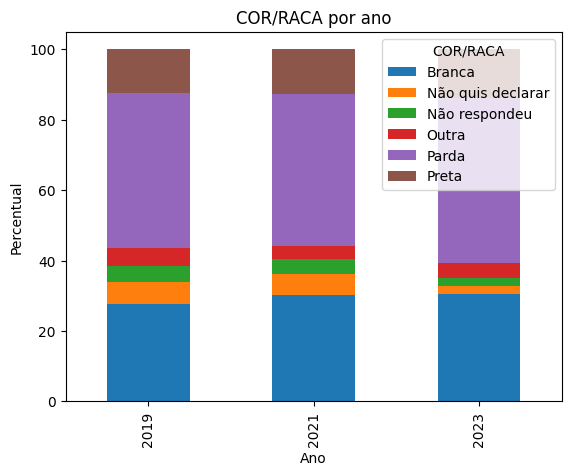

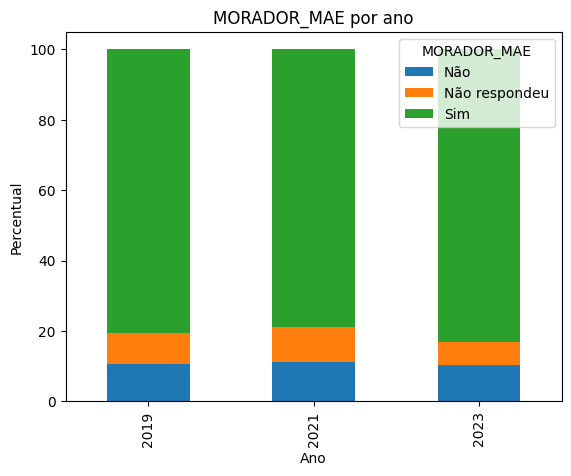

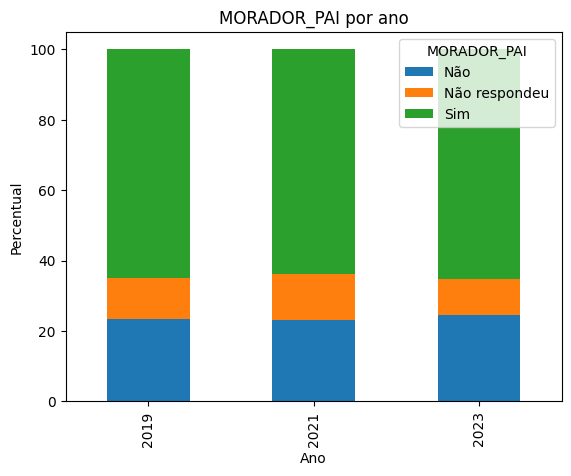

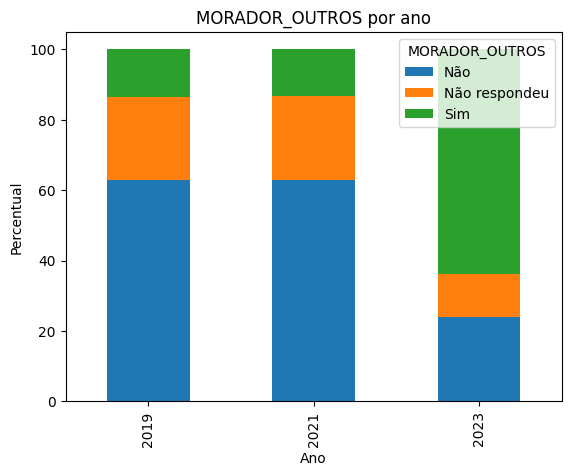

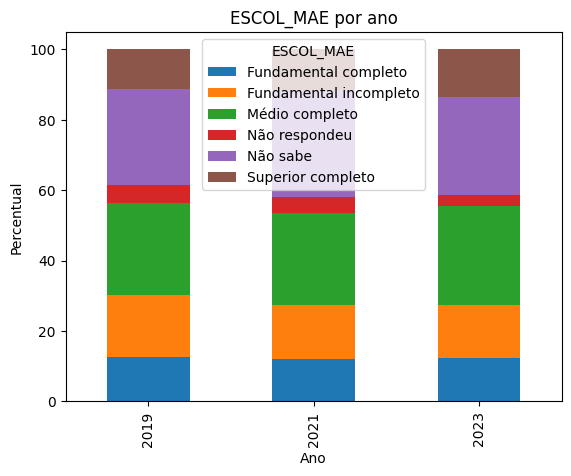

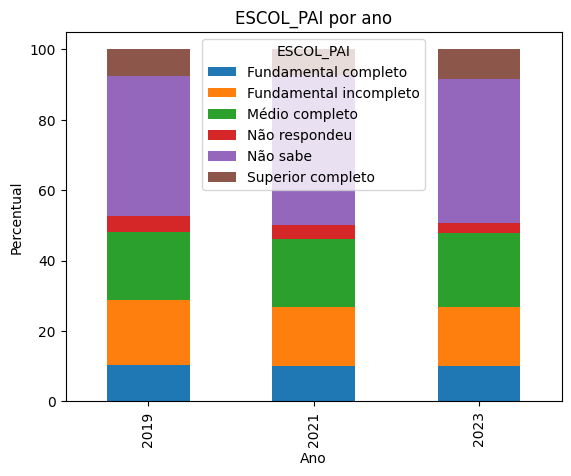

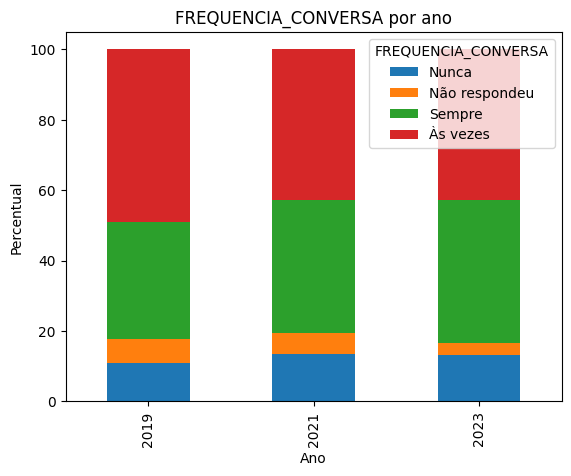

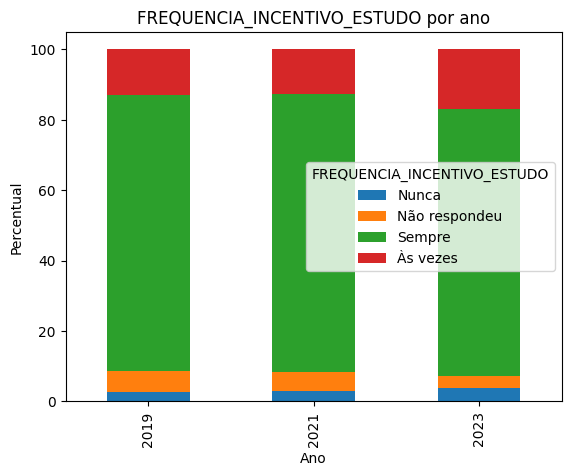

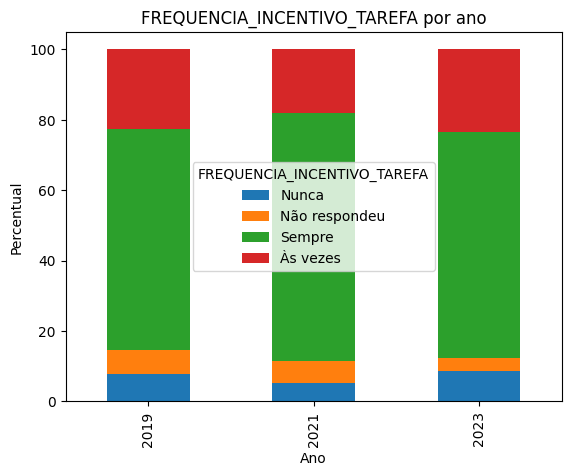

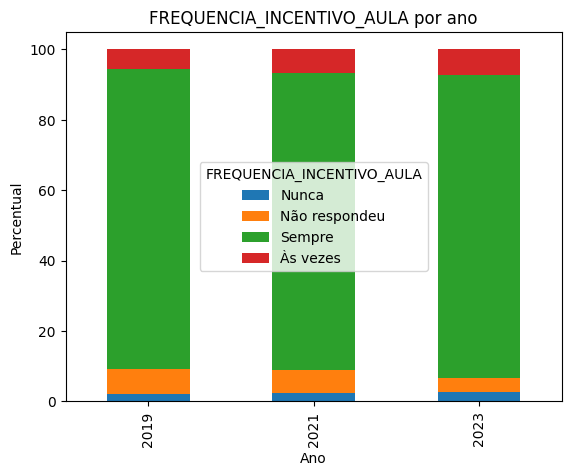

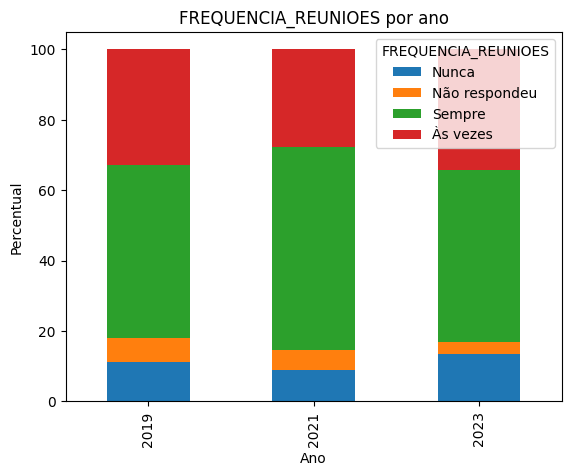

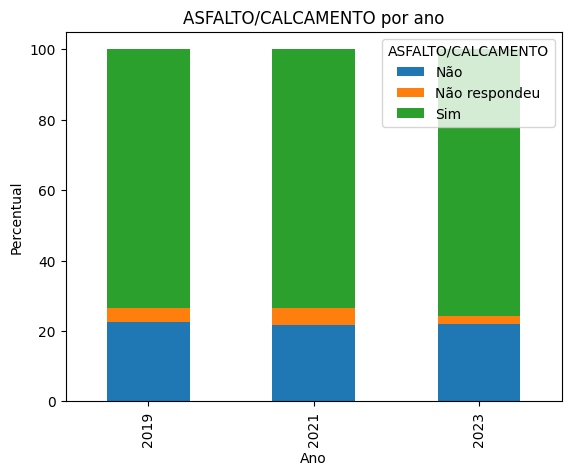

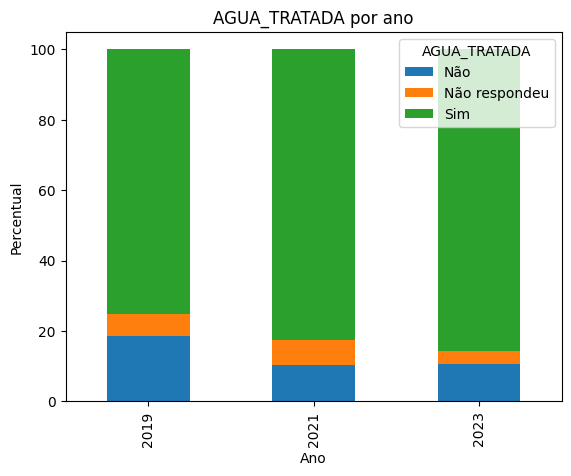

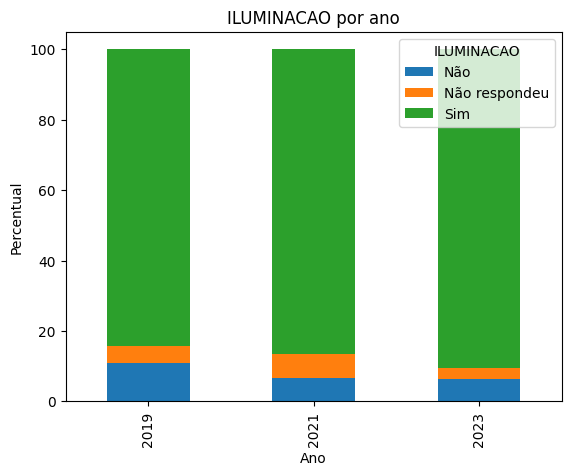

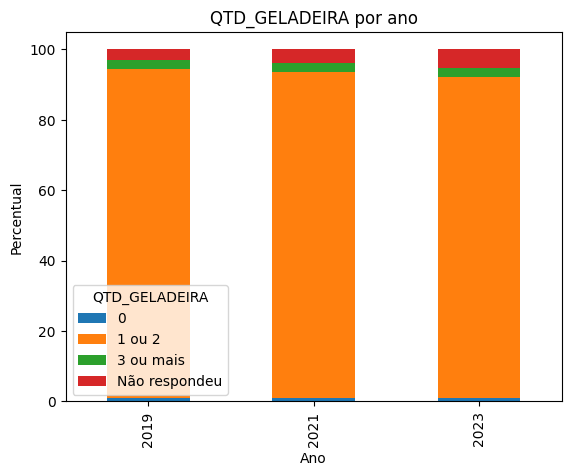

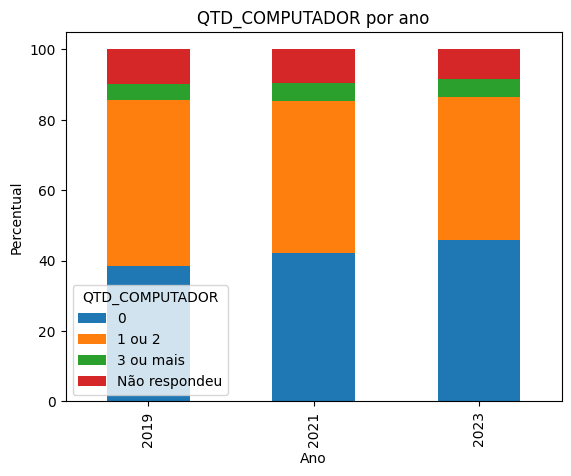

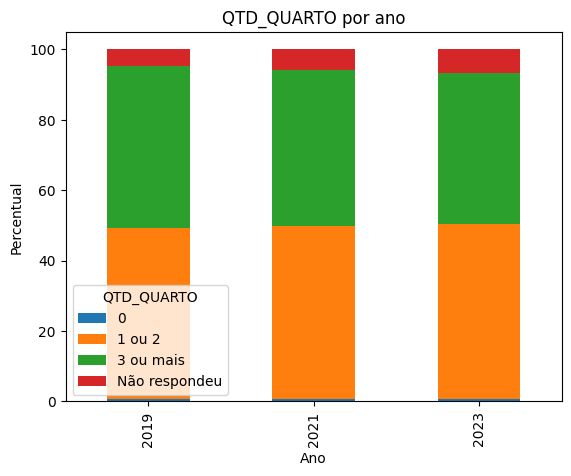

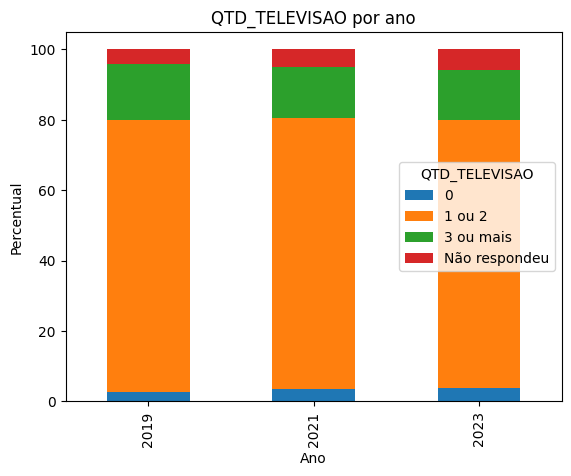

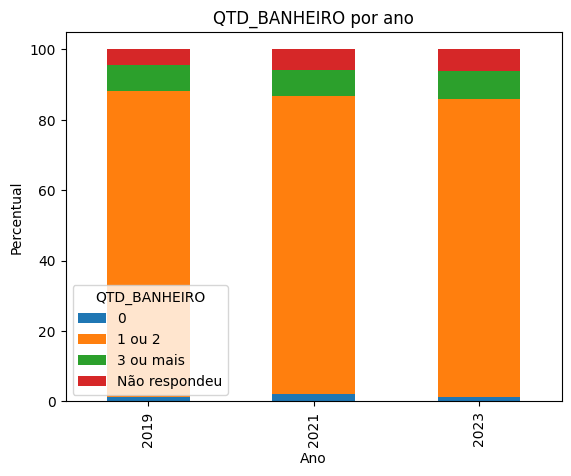

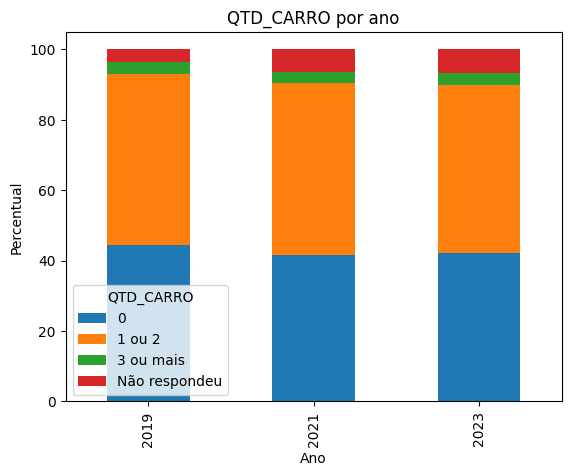

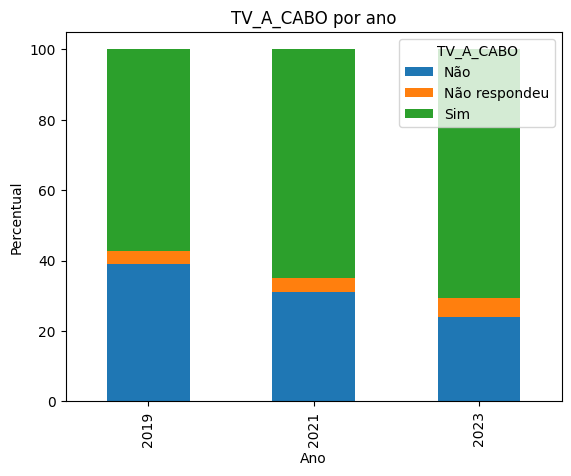

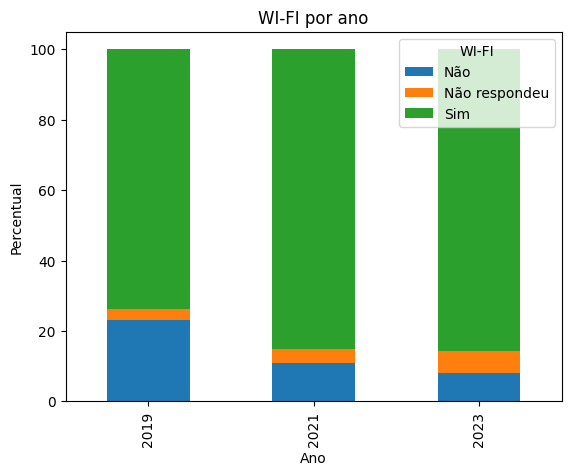

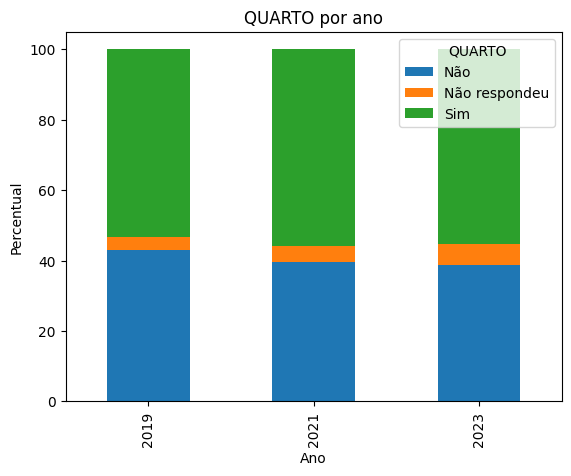

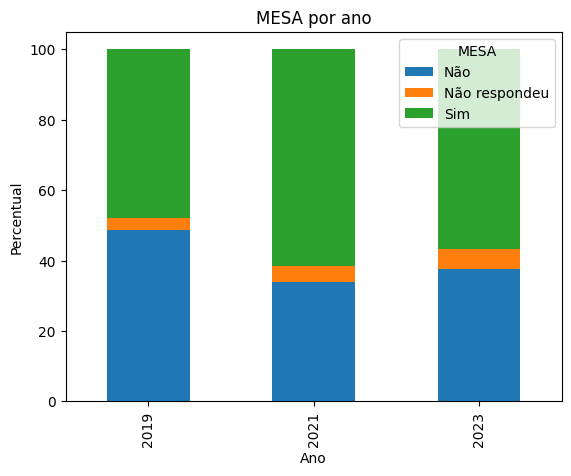

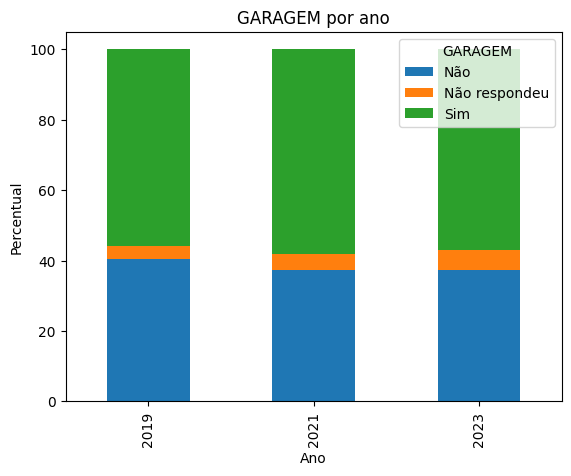

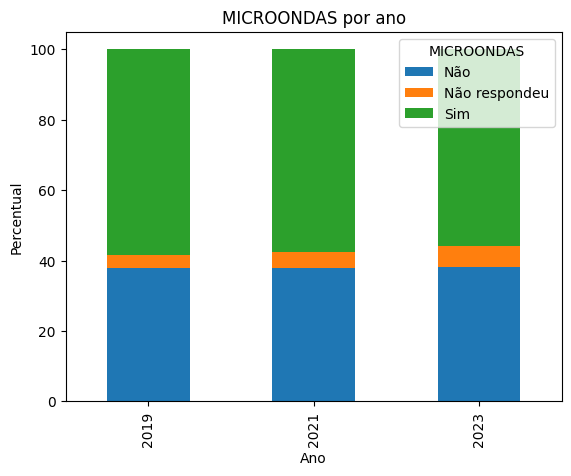

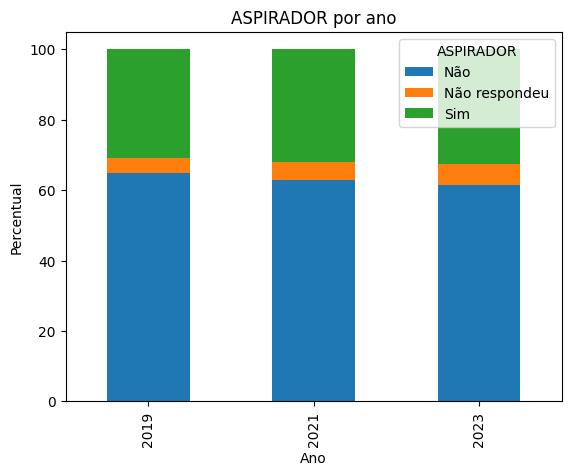

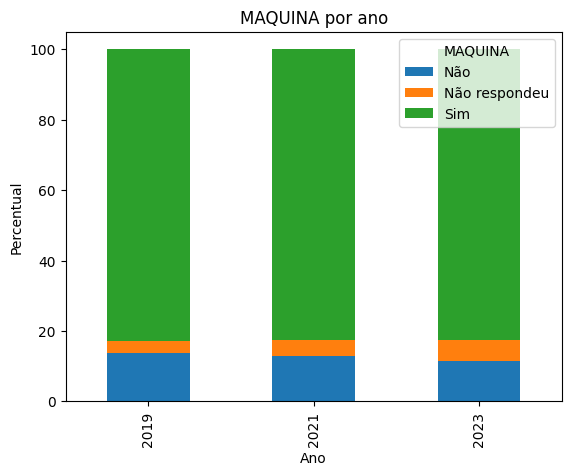

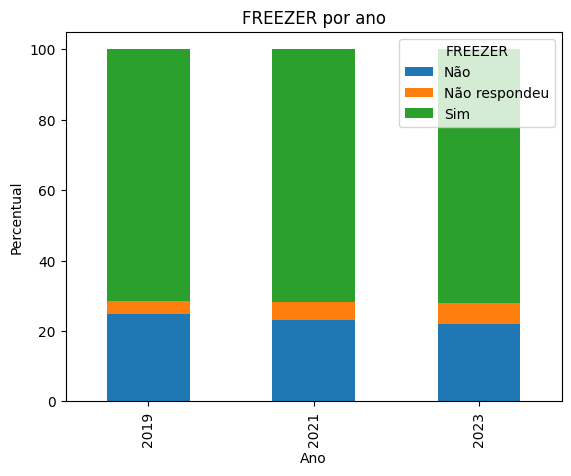

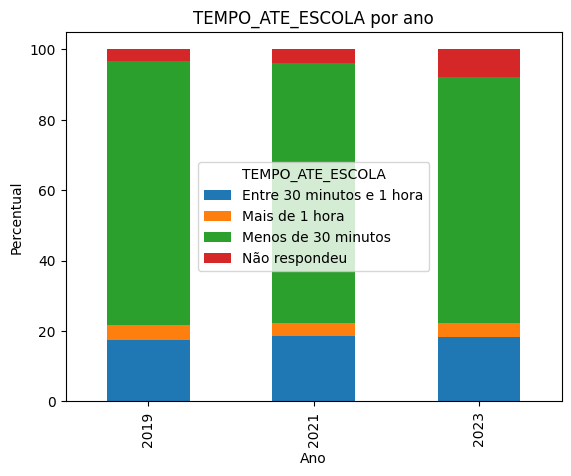

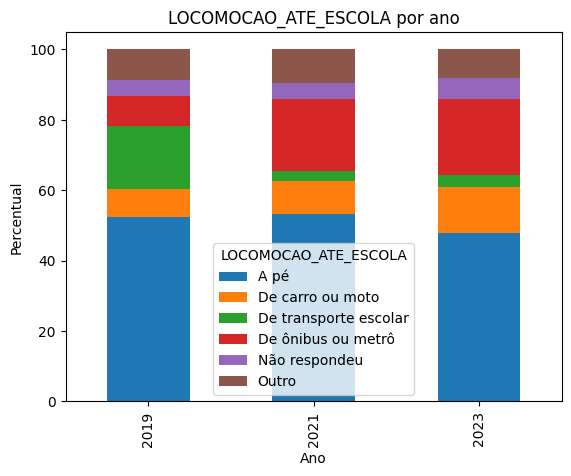

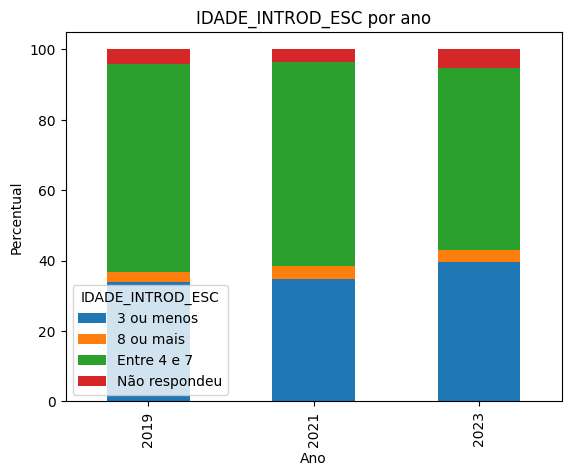

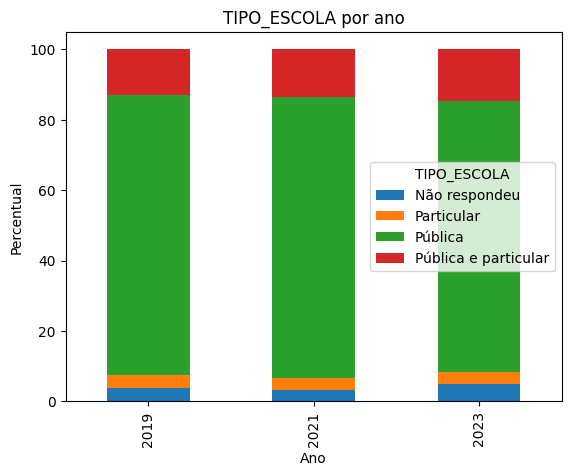

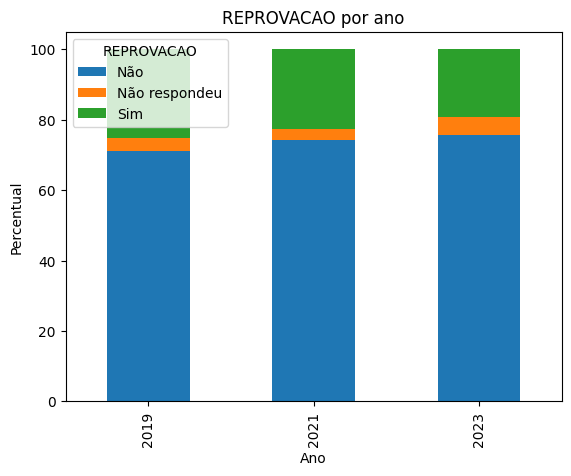

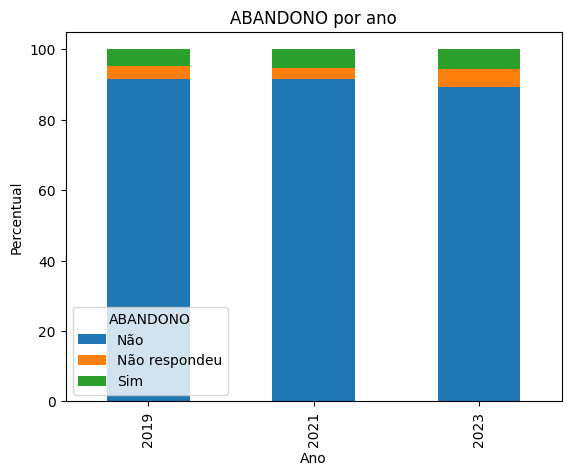

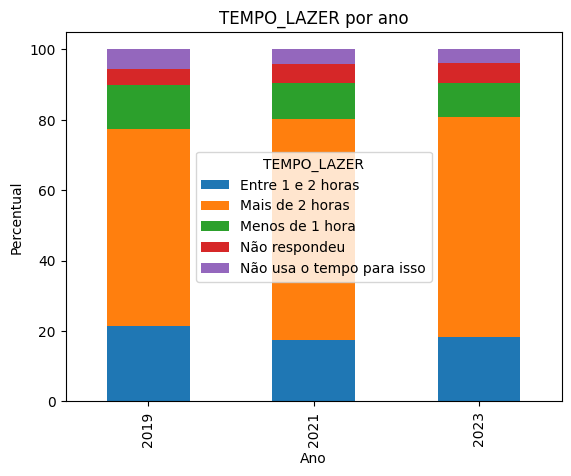

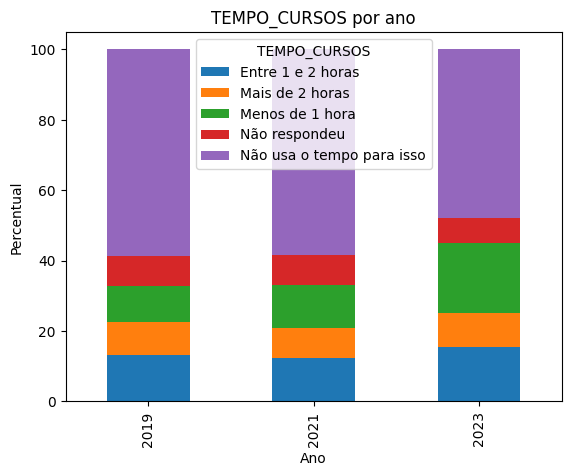

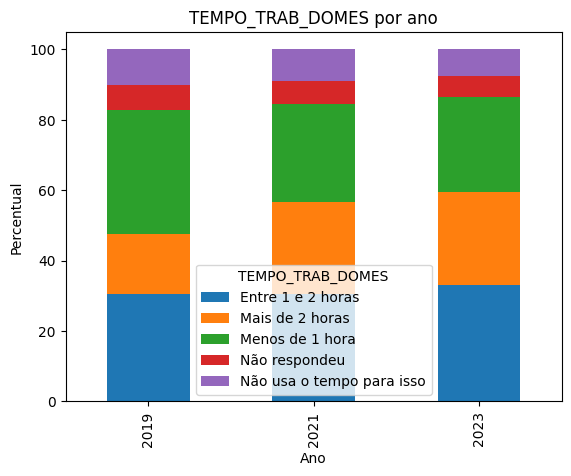

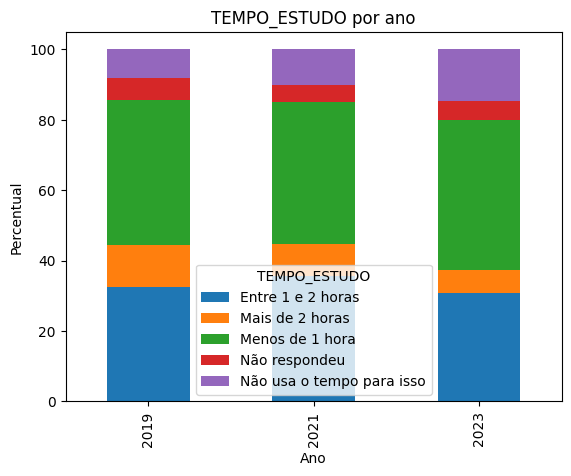

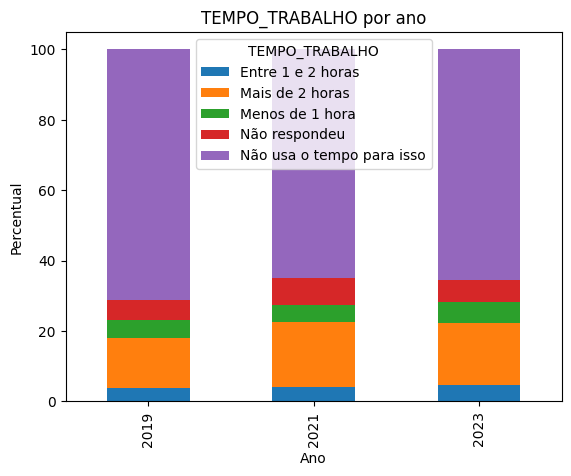

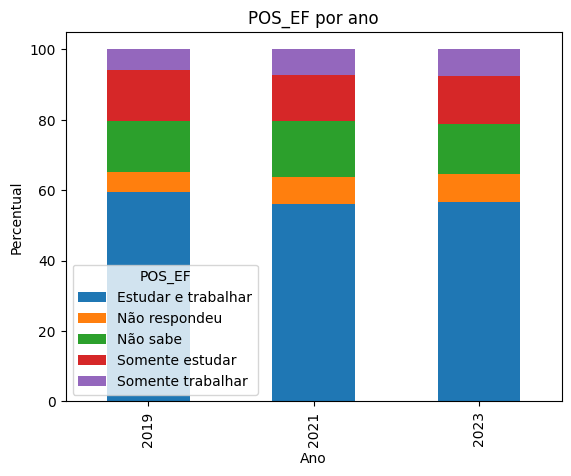

In [22]:
variaveis = [
    "LINGUA_FALADA","COR/RACA","MORADOR_MAE","MORADOR_PAI","MORADOR_OUTROS","ESCOL_MAE","ESCOL_PAI","FREQUENCIA_CONVERSA","FREQUENCIA_INCENTIVO_ESTUDO",
    "FREQUENCIA_INCENTIVO_TAREFA","FREQUENCIA_INCENTIVO_AULA","FREQUENCIA_REUNIOES","ASFALTO/CALCAMENTO","AGUA_TRATADA","ILUMINACAO","QTD_GELADEIRA",
    "QTD_COMPUTADOR","QTD_QUARTO","QTD_TELEVISAO","QTD_BANHEIRO","QTD_CARRO","TV_A_CABO","WI-FI","QUARTO","MESA","GARAGEM","MICROONDAS","ASPIRADOR",
    "MAQUINA","FREEZER","TEMPO_ATE_ESCOLA","LOCOMOCAO_ATE_ESCOLA","IDADE_INTROD_ESC","TIPO_ESCOLA","REPROVACAO","ABANDONO","TEMPO_LAZER","TEMPO_CURSOS",
    "TEMPO_TRAB_DOMES","TEMPO_ESTUDO","TEMPO_TRABALHO","POS_EF"
]
for var in variaveis:
    
    tabela = pd.crosstab(
        df_final["ANO"],
        df_final[var],
        normalize="index"
    ) * 100
    
    tabela.plot(kind="bar", stacked=True)

    plt.title(f"{var} por ano")
    plt.ylabel("Percentual")
    plt.xlabel("Ano")

    plt.show()

#### 2. Evolução da proficiência
O objetivo dessa fase foi comparar a evolução da proficiência entre os anos

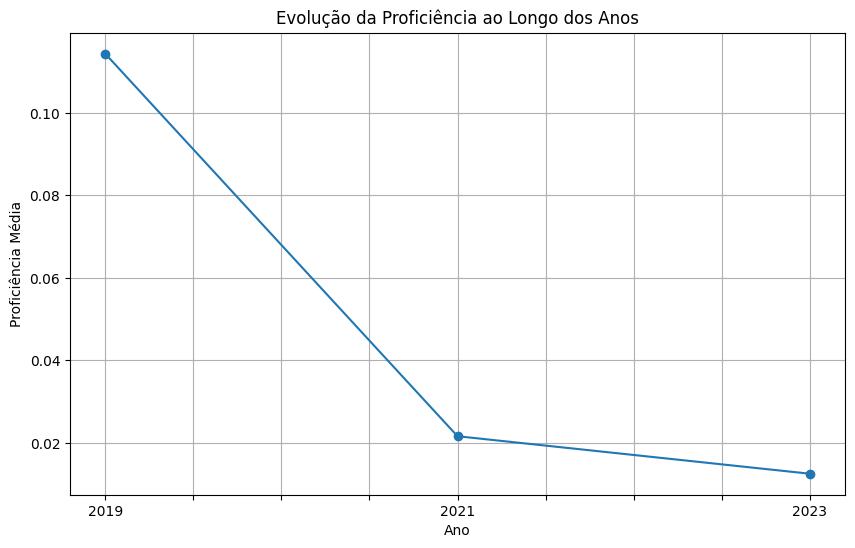

In [28]:
df_final["PROFICIENCIA_MT"] = pd.to_numeric(
    df_final["PROFICIENCIA_MT"],
    errors="coerce"
)

media_prof = df_final.groupby("ANO")["PROFICIENCIA_MT"].mean()

media_prof.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.title("Evolução da Proficiência ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Proficiência Média")

plt.grid(True)

plt.show()